In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import cmcrameri.cm as cmc




project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)
print("Project root directory:", os.getcwd())

Project root directory: c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn


In [3]:
k_start = 1
k_stop = 50
lon = 0
filetype = '.png'

model_name = f"PINN_MSO_ensemble_models_{k_start}to{k_stop}_lon_{lon}deg_profile"
pathinput = "predictions/"+model_name+".csv"
data = pd.read_csv(pathinput, header=0)
pathoutput = f'figures/profiles/PINN_MSO_ensemble_models_{k_start}to{k_stop}_profiles/'

os.makedirs(pathoutput, exist_ok=True)




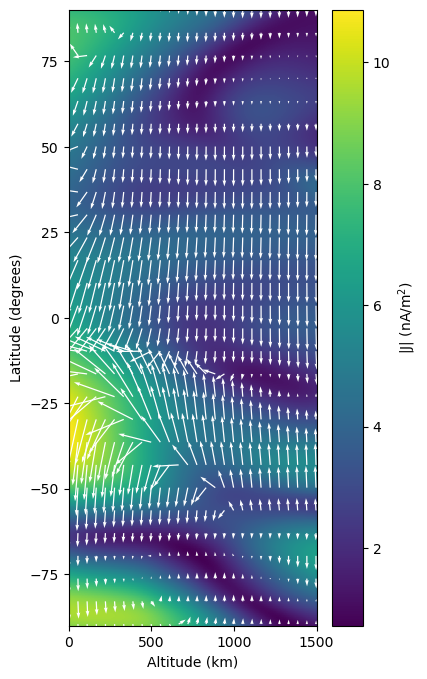

In [6]:

J_flat = np.sqrt(data['Jx'].values**2 + data['Jy'].values**2 + data['Jz'].values**2)
# cmap = cmc.imola()

lat, alt = data['lat'].values, data['alt'].values
lat_unique = np.unique(lat)[::-1]
alt_unique = np.unique(alt)
n_lat = len(lat_unique)
n_alt = len(alt_unique)
J_mesh = J_flat.reshape((n_lat, n_alt))

lat_edges = np.concatenate(([lat_unique[0] - (lat_unique[1]-lat_unique[0])/2],
                            (lat_unique[:-1] + lat_unique[1:])/2,
                            [lat_unique[-1] + (lat_unique[-1]-lat_unique[-2])/2]))
alt_edges = np.concatenate(([alt_unique[0] - (alt_unique[1]-alt_unique[0])/2],
                            (alt_unique[:-1] + alt_unique[1:])/2,
                            [alt_unique[-1] + (alt_unique[-1]-alt_unique[-2])/2]))


plt.figure(figsize=(4,8))
pcm = plt.pcolormesh(alt_edges, lat_edges, J_mesh,  shading='auto')
plt.colorbar(pcm, label='|J| (nA/m$^2$)')
plt.xlabel('Altitude (km)')
plt.ylabel('Latitude (degrees)')

plt.savefig(pathoutput+f'/J_magnitude_profile_lon_{lon}deg{filetype}', dpi=300, bbox_inches='tight')
# quiver plot of J vector field
step = 35
Jr_mesh = data['Jr'].values.reshape((n_lat, n_alt))
Jt_mesh = data['Jt'].values.reshape((n_lat, n_alt))
X, Y = np.meshgrid(alt_unique, lat_unique)
# Jt_mesh = Jt_mesh[::-1, :]
plt.quiver(X[::step, ::step], Y[::step, ::step], Jr_mesh[::step, ::step], -Jt_mesh[::step, ::step], color='white', scale=40, width=0.005, angles='xy')

plt.savefig(pathoutput+f'/J_quiver_magnitude_profile_lon_{lon}deg{filetype}', dpi=300, bbox_inches='tight')

In [5]:
print(np.pi * 3393.5)

10660.994669956963
